In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
df = pd.read_csv(("IMDb Movies India.csv"),encoding='unicode_escape')
df.head(10)

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali
5,...Aur Pyaar Ho Gaya,(1997),147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,(2005),142 min,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
7,.in for Motion,(2008),59 min,Documentary,NaN,NaN,Anirban Datta,NaN,NaN,NaN
8,?: A Question Mark,(2012),82 min,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia
9,@Andheri,(2014),116 min,"Action, Crime, Thriller",4.0,11,Biju Bhaskar Nair,Augustine,Fathima Babu,Byon


In [5]:
df.shape

(15509, 10)

In [6]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [8]:
df.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [9]:
df.duplicated().sum()

np.int64(6)

In [10]:
df.dropna(inplace=True)
df.isnull().sum()

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

In [11]:
df.drop_duplicates(inplace=True)
df.shape

(5659, 10)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5659 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      5659 non-null   object 
 1   Year      5659 non-null   object 
 2   Duration  5659 non-null   object 
 3   Genre     5659 non-null   object 
 4   Rating    5659 non-null   float64
 5   Votes     5659 non-null   object 
 6   Director  5659 non-null   object 
 7   Actor 1   5659 non-null   object 
 8   Actor 2   5659 non-null   object 
 9   Actor 3   5659 non-null   object 
dtypes: float64(1), object(9)
memory usage: 486.3+ KB


In [13]:
df.describe()

,Rating
count,5659.000000
mean,5.898533
std,1.381165
min,1.100000
25%,5.000000
50%,6.100000
75%,6.900000
max,10.000000


In [14]:
df.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

In [15]:
df['Year'] = df['Year'].fillna(0)
df['Year'] = df['Year'].replace(r'[()]', '', regex=True).astype(int)
print(df['Year'])

1        2019
3        2019
5        1997
6        2005
8        2012
         ... 
15493    2015
15494    2001
15503    1989
15505    1999
15508    1998
Name: Year, Length: 5659, dtype: int64


In [16]:
df['Duration'] = pd.to_numeric(df['Duration'].str.replace(' min', ''))
genres = df['Genre'].value_counts()
genres

Genre
Drama                              844
Drama, Romance                     332
Action, Crime, Drama               329
Action, Drama                      206
Comedy, Drama                      205
                                  ... 
Action, Comedy, War                  1
Mystery, Sci-Fi                      1
Horror, Romance, Sci-Fi              1
Romance, Musical, Drama              1
Documentary, Biography, Musical      1
Name: count, Length: 376, dtype: int64

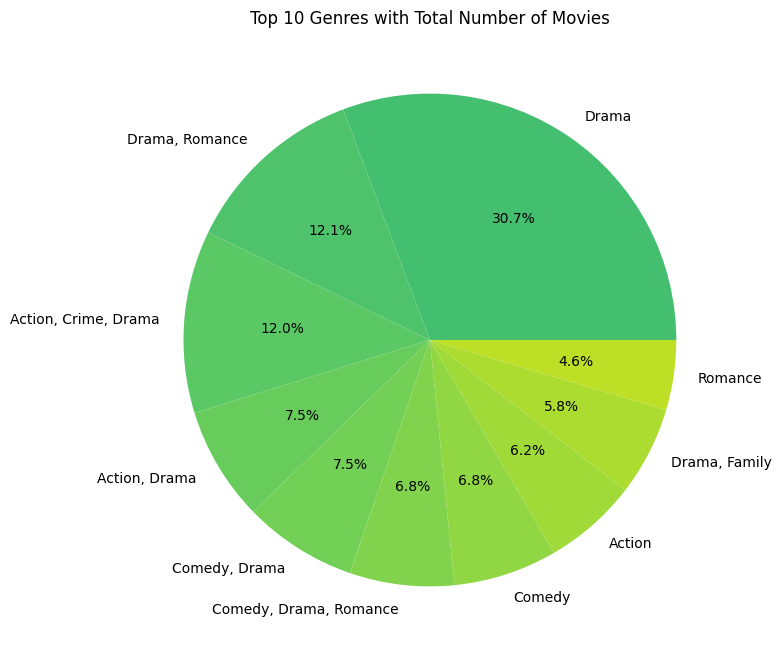

In [18]:
df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre')
df['Genre']=df['Genre'].fillna(df['Genre'].mode()[0])
top_genres = genres.head(10)
plt.figure(figsize=(8, 8))
colors = plt.cm.viridis(np.linspace(0.7, 0.9, len(top_genres)))
plt.pie(top_genres.values, labels=top_genres.index, autopct='%1.1f%%', colors=colors)
plt.title('Top 10 Genres with Total Number of Movies')
plt.show()

In [19]:
Year = df['Year'].value_counts()
Year

Year
2019    423
2013    374
2017    372
2018    358
2015    353
       ... 
1939      4
1934      3
1931      3
1933      2
1932      2
Name: count, Length: 91, dtype: int64

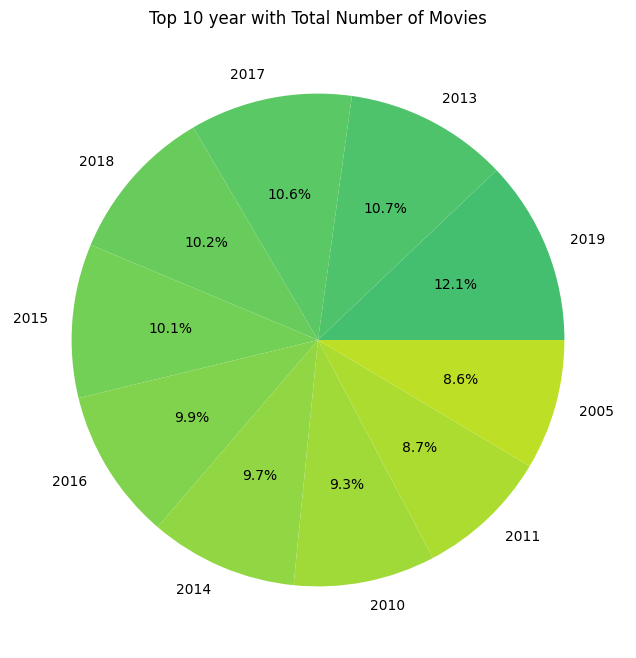

In [20]:
top_Year = Year.head(10)
plt.figure(figsize=(8, 8))
colors = plt.cm.viridis(np.linspace(0.7, 0.9, len(top_Year)))
plt.pie(top_Year.values, labels=top_Year.index, autopct='%1.1f%%', colors=colors)
plt.title('Top 10 year with Total Number of Movies')
plt.show()

In [21]:
directors = df['Director'].value_counts()
directors

Director
David Dhawan       103
Ram Gopal Varma     93
Mahesh Bhatt        87
Vikram Bhatt        80
Priyadarshan        74
                  ... 
Sridhar Reddy        1
Aziz Zee             1
Prashant Gore        1
Rajesh Bakshi        1
Ismail Darbar        1
Name: count, Length: 2431, dtype: int64

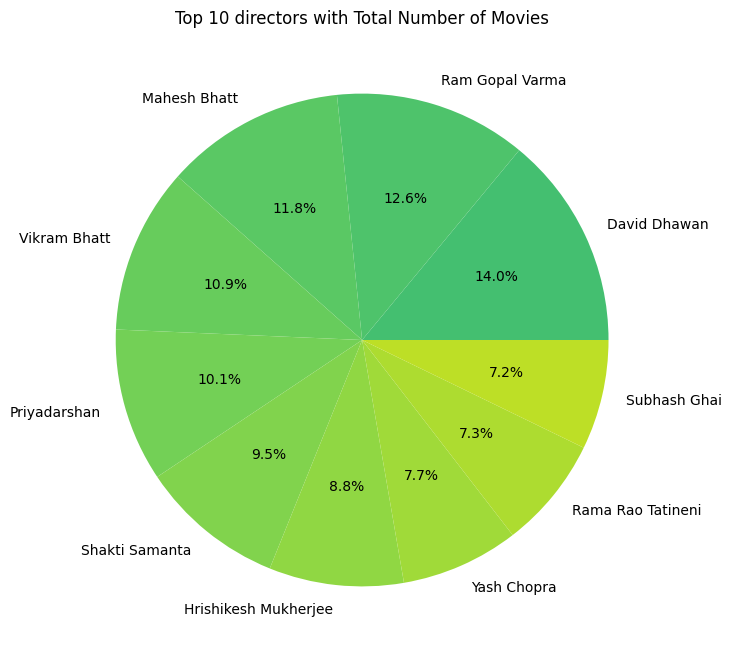

In [22]:
top_directors = directors.head(10)
plt.figure(figsize=(8, 8))
colors = plt.cm.viridis(np.linspace(0.7, 0.9, len(top_directors)))
plt.pie(top_directors.values, labels=top_directors.index, autopct='%1.1f%%', colors=colors)
plt.title('Top 10 directors with Total Number of Movies')
plt.show()

In [23]:
actors = pd.concat([df['Actor 1'], df['Actor 2'], df['Actor 3']]).value_counts()
actors

Amitabh Bachchan      375
Dharmendra            315
Akshay Kumar          315
Mithun Chakraborty    309
Ashok Kumar           266
                     ... 
Monica Aggarwal         1
Jahmil X.T. Qubeka      1
Kimti Anand             1
Amitkumar Sharma        1
Abuzar Akhtar           1
Name: count, Length: 5041, dtype: int64

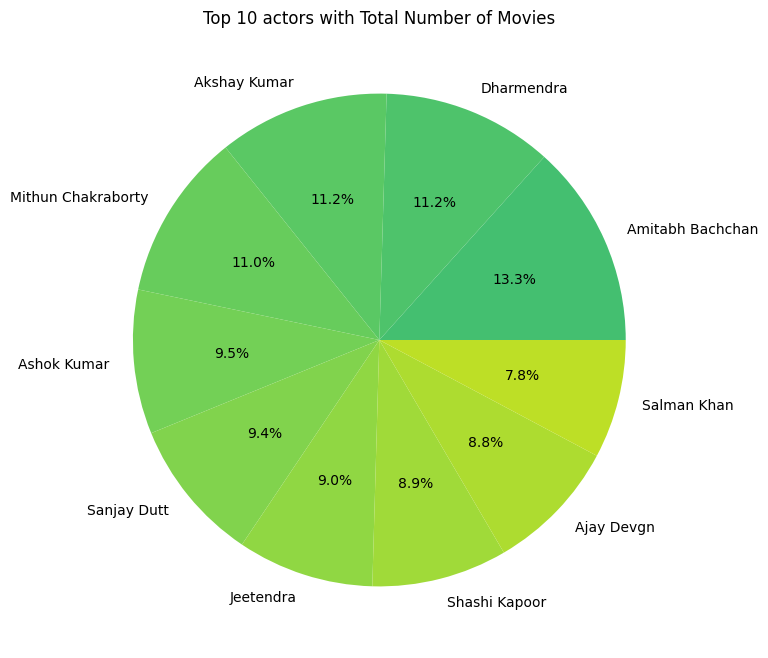

In [24]:
Top_actors = actors.head(10)
plt.figure(figsize=(8, 8))
colors = plt.cm.viridis(np.linspace(0.7, 0.9, len(Top_actors)))
plt.pie(Top_actors.values, labels=Top_actors.index, autopct='%1.1f%%', colors=colors)
plt.title('Top 10 actors with Total Number of Movies')
plt.show()

In [31]:
df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre')
df = df.reset_index(drop=True)
df['Genre'] = df['Genre'].fillna('Drama')
print(df.head(10))

                                 Name  Year  Duration  Genre  Rating  Votes  \
0  #Gadhvi (He thought he was Gandhi)  2019       109  Drama     7.0      8   
1                             #Yaaram  2019       110  Drama     4.4     35   
2                             #Yaaram  2019       110  Drama     4.4     35   
3                ...Aur Pyaar Ho Gaya  1997       147  Drama     4.7    827   
4                ...Aur Pyaar Ho Gaya  1997       147  Drama     4.7    827   
5                ...Aur Pyaar Ho Gaya  1997       147  Drama     4.7    827   
6                           ...Yahaan  2005       142  Drama     7.4  1,086   
7                           ...Yahaan  2005       142  Drama     7.4  1,086   
8                           ...Yahaan  2005       142  Drama     7.4  1,086   
9                  ?: A Question Mark  2012        82  Drama     5.6    326   

         Director          Actor 1                 Actor 2          Actor 3  
0   Gaurav Bakshi     Rasika Dugal          Vivek Gh

In [32]:
def clean_duration(duration):
    if isinstance(duration, str):
        return float(''.join(filter(str.isdigit, duration)))
    return duration
df['Duration'] = df['Duration'].apply(clean_duration)
df['Votes'] = df['Votes'].astype(str)
df['Votes'] = df['Votes'].str.replace(',', '').astype(int)
df['Year'] = df['Year'].astype(str)
df['Year'] = df['Year'].str.strip('()').astype(int)
df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11979 entries, 0 to 11978
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      11979 non-null  object 
 1   Year      11979 non-null  int64  
 2   Duration  11979 non-null  int64  
 3   Genre     11979 non-null  object 
 4   Rating    11979 non-null  float64
 5   Votes     11979 non-null  int64  
 6   Director  11979 non-null  object 
 7   Actor 1   11979 non-null  object 
 8   Actor 2   11979 non-null  object 
 9   Actor 3   11979 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 936.0+ KB


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,#Gadhvi (He thought he was Gandhi),2019,109,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
1,#Yaaram,2019,110,Drama,4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
2,#Yaaram,2019,110,Drama,4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
3,...Aur Pyaar Ho Gaya,1997,147,Drama,4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
4,...Aur Pyaar Ho Gaya,1997,147,Drama,4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
...,...,...,...,...,...,...,...,...,...,...
11974,Zulm Ki Zanjeer,1989,125,Drama,5.8,44,S.P. Muthuraman,Chiranjeevi,Jayamalini,Rajinikanth
11975,Zulmi,1999,129,Drama,4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani
11976,Zulmi,1999,129,Drama,4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani
11977,Zulm-O-Sitam,1998,130,Drama,6.2,20,K.C. Bokadia,Dharmendra,Jaya Prada,Arjun Sarja


In [33]:
df = df.drop(columns=['Name'])
actor1_encoding_map = df.groupby('Actor 1').agg({'Rating': 'mean'}).to_dict()
actor2_encoding_map = df.groupby('Actor 2').agg({'Rating': 'mean'}).to_dict()
actor3_encoding_map = df.groupby('Actor 3').agg({'Rating': 'mean'}).to_dict()
director_encoding_map = df.groupby('Director').agg({'Rating': 'mean'}).to_dict()
genre_encoding_map = df.groupby('Genre').agg({'Rating': 'mean'}).to_dict()
df['encoded_actor1'] = round(df['Actor 1'].map(actor1_encoding_map['Rating']),1)
df['encoded_actor2'] = round(df['Actor 2'].map(actor2_encoding_map['Rating']),1)
df['encoded_actor3'] = round(df['Actor 3'].map(actor3_encoding_map['Rating']),1)
df['encoded_director'] = round(df['Director'].map(director_encoding_map['Rating']),1)
df['encoded_genre'] = round(df['Genre'].map(genre_encoding_map['Rating']),1)
df.drop(['Actor 1', 'Actor 2', 'Actor 3', 'Director', 'Genre'], axis=1, inplace=True)
df

,Year,Duration,Rating,Votes,encoded_actor1,encoded_actor2,encoded_actor3,encoded_director,encoded_genre
0,2019,109,7.0,8,6.8,7.0,7.0,7.0,5.9
1,2019,110,4.4,35,5.2,4.4,4.5,4.4,5.9
2,2019,110,4.4,35,5.2,4.4,4.5,4.4,5.9
3,1997,147,4.7,827,4.8,5.7,5.9,5.3,5.9
4,1997,147,4.7,827,4.8,5.7,5.9,5.3,5.9
...,...,...,...,...,...,...,...,...,...
11974,1989,125,5.8,44,6.4,5.8,6.0,6.3,5.9
11975,1999,129,4.5,655,5.4,4.6,5.8,5.2,5.9
11976,1999,129,4.5,655,5.4,4.6,5.8,5.2,5.9
11977,1998,130,6.2,20,6.0,5.6,5.8,4.1,5.9


In [34]:
test_data = df.drop(columns=['Rating'])
test_data

,Year,Duration,Votes,encoded_actor1,encoded_actor2,encoded_actor3,encoded_director,encoded_genre
0,2019,109,8,6.8,7.0,7.0,7.0,5.9
1,2019,110,35,5.2,4.4,4.5,4.4,5.9
2,2019,110,35,5.2,4.4,4.5,4.4,5.9
3,1997,147,827,4.8,5.7,5.9,5.3,5.9
4,1997,147,827,4.8,5.7,5.9,5.3,5.9
...,...,...,...,...,...,...,...,...
11974,1989,125,44,6.4,5.8,6.0,6.3,5.9
11975,1999,129,655,5.4,4.6,5.8,5.2,5.9
11976,1999,129,655,5.4,4.6,5.8,5.2,5.9
11977,1998,130,20,6.0,5.6,5.8,4.1,5.9


In [35]:
ratings = df['Rating']
ratings

0        7.0
1        4.4
2        4.4
3        4.7
4        4.7
        ... 
11974    5.8
11975    4.5
11976    4.5
11977    6.2
11978    6.2
Name: Rating, Length: 11979, dtype: float64

In [39]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(test_data,ratings,test_size=0.25,random_state=52)
print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

(8984, 8) (2995, 8) (8984,) (2995,)


In [43]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
ridge_model = Ridge()
ridge_model.fit(X_train, Y_train)
Ridge()
X_test_prediction = ridge_model.predict(X_test)
mse = mean_squared_error(Y_test, X_test_prediction)
mae = mean_absolute_error(Y_test, X_test_prediction)
r2 = r2_score(Y_test, X_test_prediction)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared (R2) Score:", r2)
results = pd.DataFrame({
    'Actual': Y_test,  
    'Predicted': X_test_prediction  
})
results['Squared Error'] = (results['Actual'] - results['Predicted'])**2  
results['Absolute Error'] = abs(results['Actual'] - results['Predicted'])  
results

Mean Squared Error: 0.4653647804906579
Mean Absolute Error: 0.49842167401854526
R-squared (R2) Score: 0.7584452196849166


,Actual,Predicted,Squared Error,Absolute Error
1778,7.5,6.824507,0.456290,0.675493
6736,6.0,6.322348,0.103908,0.322348
9964,5.1,4.584677,0.265557,0.515323
5707,6.7,6.564205,0.018440,0.135795
3811,5.4,5.172873,0.051587,0.227127
...,...,...,...,...
11249,3.7,3.663003,0.001369,0.036997
6301,5.2,4.873134,0.106841,0.326866
1422,4.6,4.136527,0.214807,0.463473
10404,6.8,6.462298,0.114043,0.337702


In [44]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, Y_train)
rf_predictions = rf_model.predict(X_test)
mse_rf  = mean_squared_error(Y_test, rf_predictions)
mae_rf  = mean_absolute_error(Y_test, rf_predictions)
r2_rf   = r2_score(Y_test, rf_predictions)
print("Random Forest Results:")
print("Mean Squared Error:", mse_rf)
print("Mean Absolute Error:", mae_rf)
print("R-squared (R2) Score:", r2_rf)

Random Forest Results:
Mean Squared Error: 0.12881812520868113
Mean Absolute Error: 0.18201702838063447
R-squared (R2) Score: 0.9331349615616034


In [45]:
results = pd.DataFrame({
    'Actual': Y_test,
    'Predicted': X_test_prediction
})
results['Squared Error'] = (results['Actual'] - results['Predicted'])**2
results['Absolute Error'] = abs(results['Actual'] - results['Predicted'])
results

,Actual,Predicted,Squared Error,Absolute Error
1778,7.5,6.824507,0.456290,0.675493
6736,6.0,6.322348,0.103908,0.322348
9964,5.1,4.584677,0.265557,0.515323
5707,6.7,6.564205,0.018440,0.135795
3811,5.4,5.172873,0.051587,0.227127
...,...,...,...,...
11249,3.7,3.663003,0.001369,0.036997
6301,5.2,4.873134,0.106841,0.326866
1422,4.6,4.136527,0.214807,0.463473
10404,6.8,6.462298,0.114043,0.337702


In [46]:
feature_names = test_data.columns
coefficients = ridge_model.coef_
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})
coef_df = coef_df.sort_values('Coefficient', ascending=False)
print("Feature Coefficients:")
print(coef_df)

Feature Coefficients:
            Feature   Coefficient
6  encoded_director  4.282221e-01
5    encoded_actor3  3.489968e-01
4    encoded_actor2  3.044952e-01
3    encoded_actor1  2.162464e-01
1          Duration  2.918895e-03
0              Year  1.589406e-03
2             Votes  4.806215e-06
7     encoded_genre  5.653677e-27


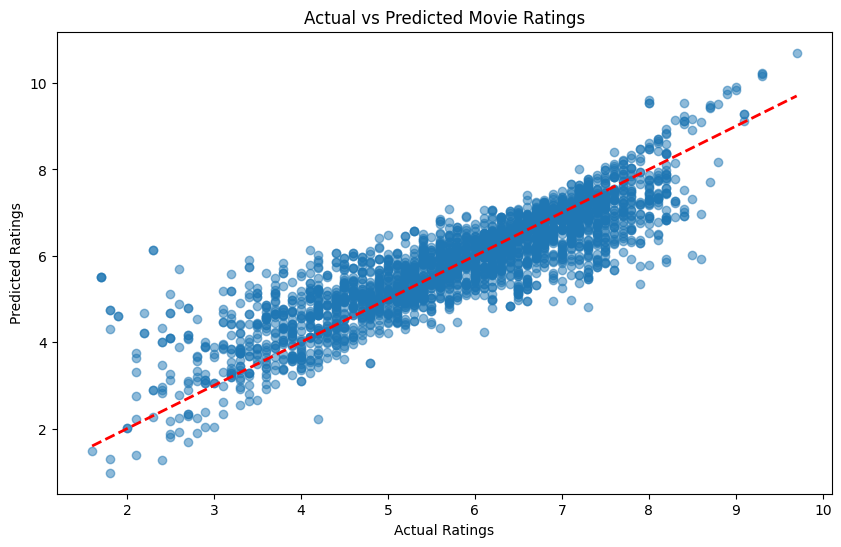

In [47]:
plt.figure(figsize=(10, 6))
plt.scatter(Y_test, X_test_prediction, alpha=0.5)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.title('Actual vs Predicted Movie Ratings')
plt.show()

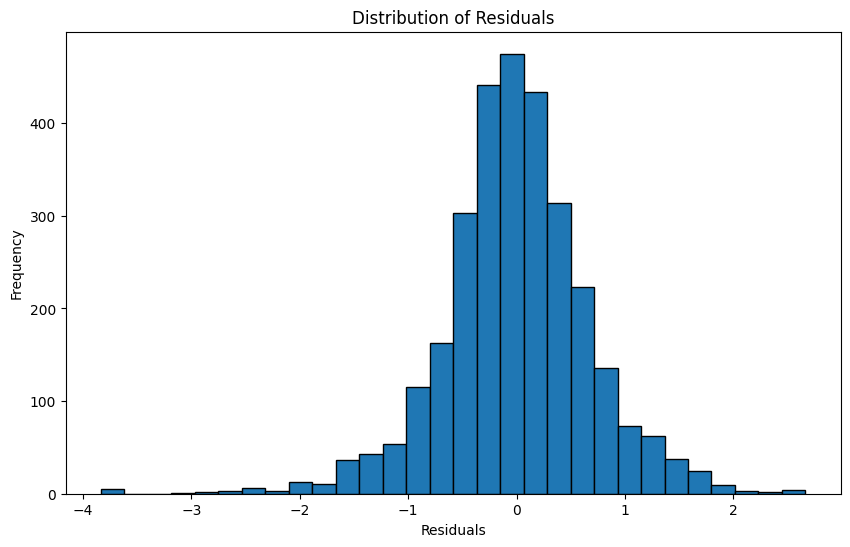

In [48]:
residuals = Y_test - X_test_prediction
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()